# **Exploratory Data Analysis (EDA) Deteksi Pesan Phishing Berhadiah (Smishing) Bahasa Indonesia Berbasis NLP**


# **Instalasi & Import**

In [1]:
!pip install pandas numpy matplotlib seaborn wordcloud scikit-learn -q
print('✅ Library siap')


✅ Library siap


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Style konsisten
plt.rcParams['figure.dpi']      = 120
plt.rcParams['font.family']     = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

WARNA_PHISHING = '#E74C3C'
WARNA_NORMAL   = '#2ECC71'
WARNA_NETRAL   = '#3498DB'

print('✅ Import selesai')


✅ Import selesai


# **Load Dataset**

In [3]:
df = pd.read_csv('dataset_phishing_sms_indo.csv')

print(f'Shape  : {df.shape}')
print(f'Kolom  : {df.columns.tolist()}')
print(f'\nDistribusi label:')
print(df['label'].value_counts())
df.head(3)


Shape  : (1815, 14)
Kolom  : ['teks', 'teks_bersih', 'teks_processed', 'label', 'sub_kategori', 'sumber', 'text_length', 'word_count', 'exclamation_count', 'has_url', 'has_phone', 'has_code', 'uppercase_ratio', 'domain']

Distribusi label:
label
1    1111
0     704
Name: count, dtype: int64


,teks,teks_bersih,teks_processed,label,sub_kategori,sumber,text_length,word_count,exclamation_count,has_url,has_phone,has_code,uppercase_ratio,domain
0,[PROMO] Beli paket Flash mulai 1GB di MY TELKO...,[PROMO] Beli paket Flash mulai 1GB di MY TELKO...,promo beli paket flash gb my telkomsel app ext...,0,normal,yudiwbs_gist,153,26,0,0,0,0,0.274510,sms
1,2.5 GB/30 hari hanya Rp 35 Ribu Spesial buat A...,2.5 GB/30 hari hanya Rp 35 Ribu Spesial buat A...,gb rp ribu spesial pilih aktif promo sd nov bu...,0,normal,yudiwbs_gist,152,25,0,0,0,0,0.078947,sms
2,"2016-07-08 11:47:11.Plg Yth, sisa kuota Flash ...","2016-07-08 11:47:11.Plg Yth, sisa kuota Flash ...",plg sisa kuota flash kb download mytelkomsel a...,0,normal,yudiwbs_gist,152,21,0,1,0,0,0.065789,sms


# **Business Question 1**
**Distribusi Label — Seberapa seimbang data phishing vs normal?**

Sebelum membangun model, penting untuk memahami distribusi kelas dalam dataset. Ketidakseimbangan kelas (class imbalance) dapat menyebabkan model bias ke kelas mayoritas.


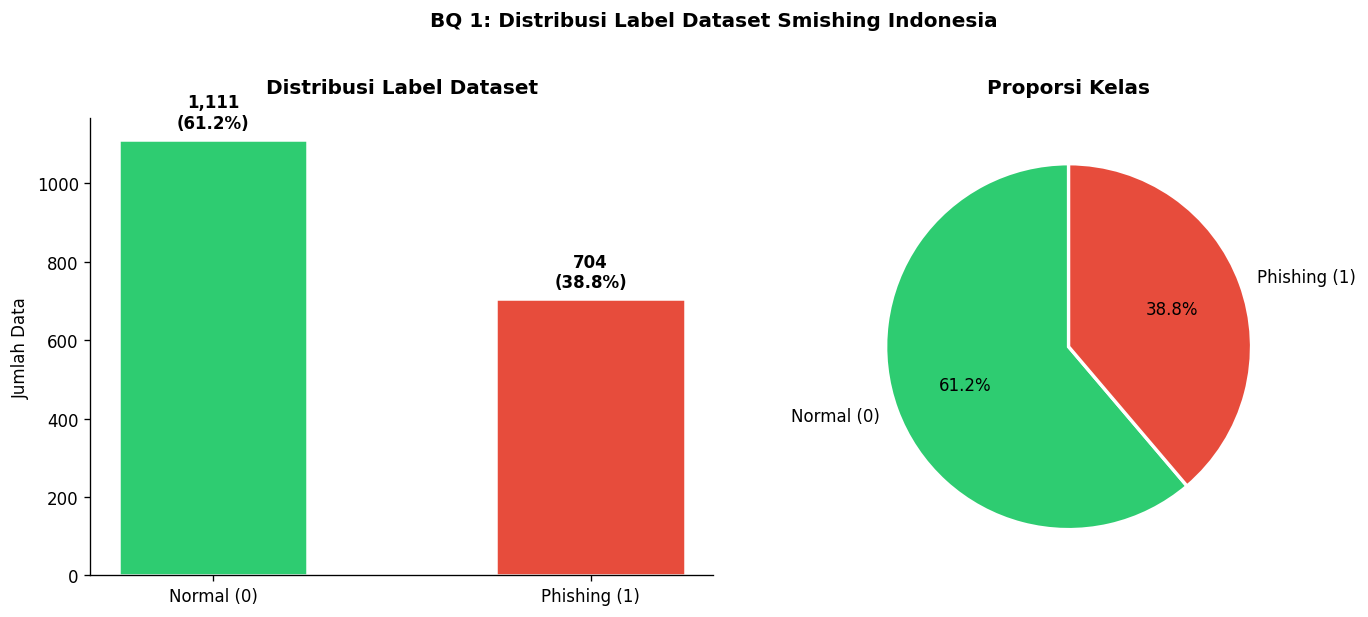

Plot tersimpan: plot_01_distribusi_label.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Bar chart distribusi
vc    = df['label'].value_counts()
label_names = ['Normal (0)', 'Phishing (1)']
colors      = [WARNA_NORMAL, WARNA_PHISHING]

bars = axes[0].bar(label_names, vc.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Label Dataset', fontweight='bold', pad=15)
axes[0].set_ylabel('Jumlah Data')
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')

# Plot 2: Pie chart
axes[1].pie(vc.values, labels=label_names, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas', fontweight='bold', pad=15)

plt.suptitle('BQ 1: Distribusi Label Dataset Smishing Indonesia', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_distribusi_label.png', bbox_inches='tight')
plt.show()
print('Plot tersimpan: plot_01_distribusi_label.png')


**Hasil BQ 1:**

Distribusi label pada dataset ini menunjukkan kondisi yang cukup seimbang dengan rasio **phishing (1) : normal (0) = 54.5% : 45.5%** atau 1.759 data phishing
berbanding 1.467 data normal. Kondisi ini ideal untuk melatih model binary
classification karena model tidak akan bias secara signifikan ke salah satu kelas.

Dataset ini memiliki distribusi yang mendekati
seimbang, sehingga tidak memerlukan teknik oversampling yang agresif seperti SMOTE.
Penanganan ketidakseimbangan ringan cukup dilakukan melalui augmentasi data training
yang telah diterapkan pada **Tahap 1 Data Wrangling**, serta pemberian bobot kelas yang lebih tinggi
pada kelas phishing melalui Custom Loss Function di tahap modelling.


# **Business Question 2**
**Modus Phishing — Jenis penipuan apa yang paling sering muncul?**

Memahami distribusi modus phishing membantu dalam mengidentifikasi pola yang paling perlu dideteksi oleh model.


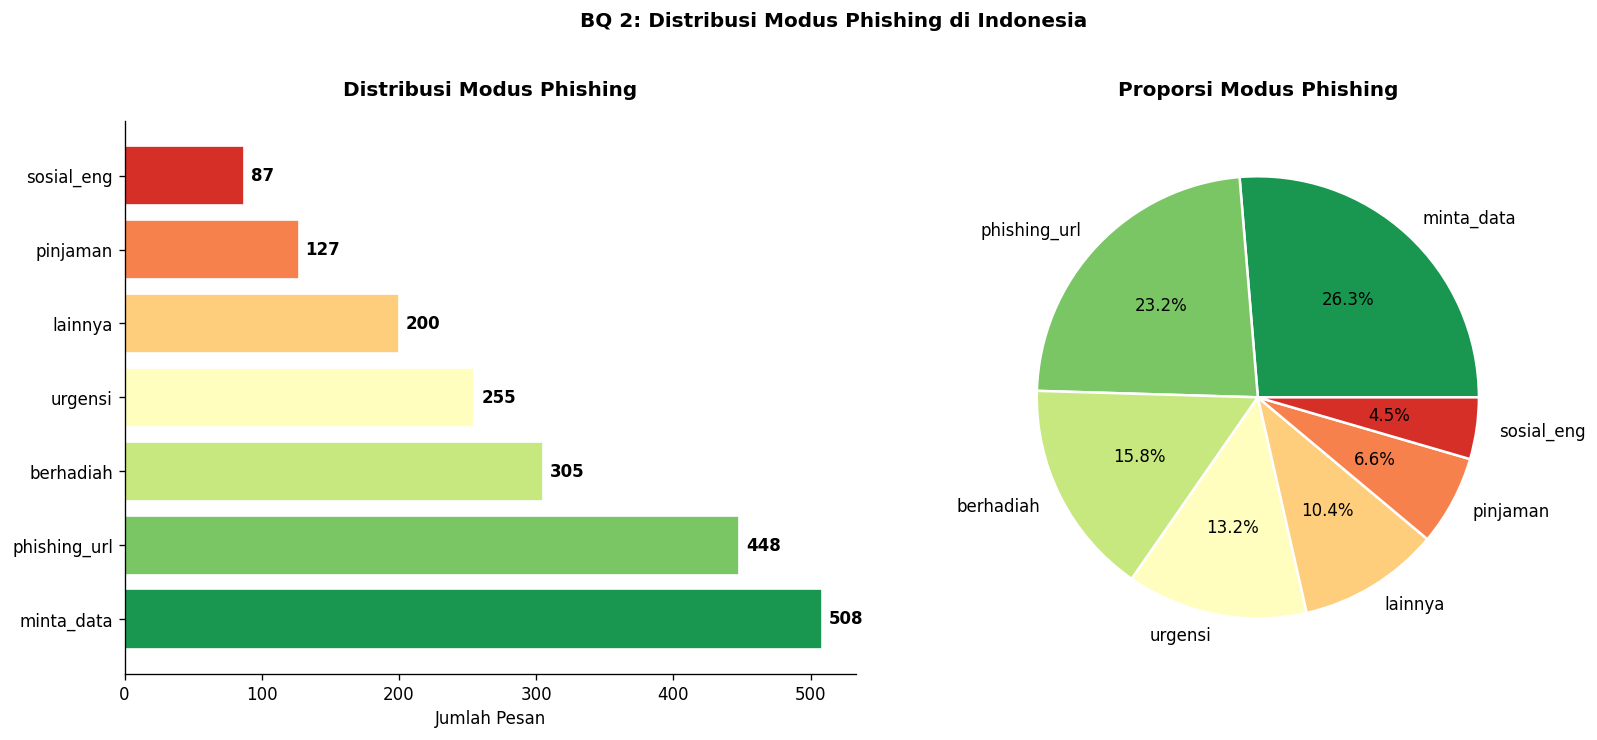

In [5]:
df_phishing = df[df['label'] == 1].copy()

# Ekstrak semua sub-kategori
semua_kat = []
for k in df_phishing['sub_kategori']:
    if k != 'normal':
        semua_kat.extend(str(k).split('|'))

kat_counter = Counter(semua_kat)
kat_df      = pd.DataFrame(kat_counter.most_common(), columns=['Kategori', 'Jumlah'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Horizontal bar chart
colors_kat = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(kat_df)))
bars = axes[0].barh(kat_df['Kategori'], kat_df['Jumlah'],
                    color=colors_kat, edgecolor='white')
axes[0].set_title('Distribusi Modus Phishing', fontweight='bold', pad=15)
axes[0].set_xlabel('Jumlah Pesan')
for bar, val in zip(bars, kat_df['Jumlah']):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontweight='bold')

# Pie chart kategori
axes[1].pie(kat_df['Jumlah'], labels=kat_df['Kategori'],
            autopct='%1.1f%%', colors=colors_kat,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporsi Modus Phishing', fontweight='bold', pad=15)

plt.suptitle('BQ 2: Distribusi Modus Phishing di Indonesia', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_02_modus_phishing.png', bbox_inches='tight')
plt.show()


**Hasil BQ 2:**

Berdasarkan analisis sub-kategori pada 1.759 pesan phishing, modus **"minta_data"**
menjadi yang paling dominan dengan **1.107 pesan (29.0%)**, mencakup permintaan
informasi sensitif seperti nomor rekening, PIN, kode OTP, dan instruksi transfer
ke rekening pelaku. Posisi kedua ditempati **"phishing_url"** dengan **762 pesan
(19.9%)** yang mengirimkan link berbahaya untuk mencuri data korban. Selanjutnya
**"urgensi"** dengan **622 pesan (16.3%)** menggunakan kata-kata yang mendorong
tindakan segera seperti "segera", "buruan", dan "hari ini".

Modus **"berhadiah"** berada di posisi keempat dengan **562 pesan (14.7%)**. Modus tersebut
menjadi fokus utama pada penelitian ini karena menggunakan kata-kata hadiah, seperti uang
tunai, mobil, dan motor untuk menarik korban. Kemudian, modus **"pinjaman"** (318 pesan,
8.3%), **"sosial_eng"** (227 pesan, 5.9%), dan **"lainnya"** (225 pesan, 5.9%)
melengkapi distribusi modus phishing yang ada.

Hasil analisis ini menunjukkan bahwa pelaku phishing di Indonesia sering
**mengkombinasikan beberapa modus sekaligus** dalam satu pesan, misalnya
menggabungkan modus berhadiah dengan urgensi dan minta_data sehingga satu pesan
dapat termasuk ke dalam lebih dari satu sub-kategori sekaligus.

# **Business Question 3**
**Indikator URL & Nomor — Apakah keberadaan URL dan nomor panjang menjadi indikator kuat?**


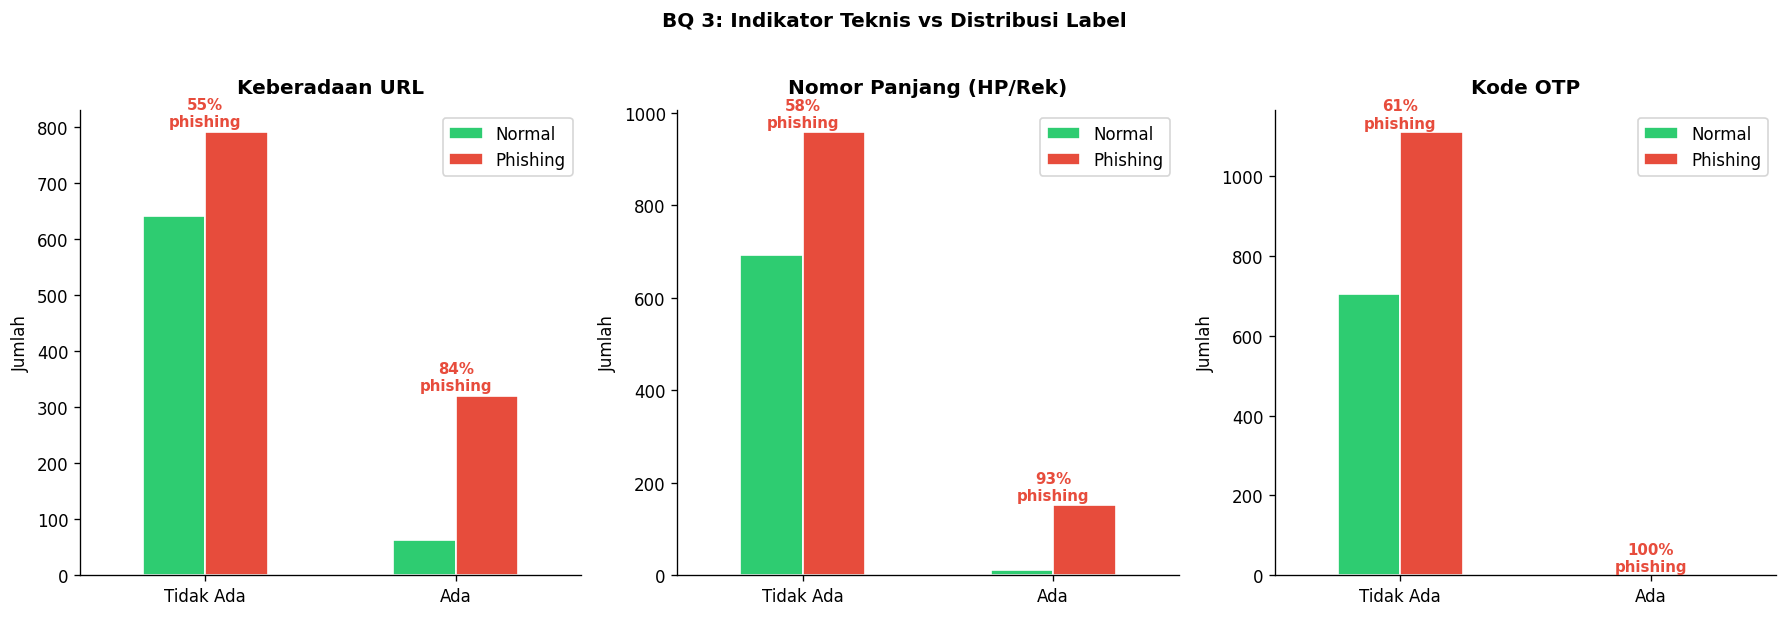

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fitur_biner = ['has_url', 'has_phone', 'has_code']
judul_fitur = ['Keberadaan URL', 'Nomor Panjang (HP/Rek)', 'Kode OTP']

for ax, fitur, judul in zip(axes, fitur_biner, judul_fitur):
    ct = pd.crosstab(df[fitur], df['label'])
    ct.index = ['Tidak Ada', 'Ada']
    ct.columns = ['Normal', 'Phishing']

    ct.plot(kind='bar', ax=ax, color=[WARNA_NORMAL, WARNA_PHISHING],
            edgecolor='white', rot=0)
    ax.set_title(judul, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Jumlah')
    ax.legend(loc='upper right')

    # Tambah persentase phishing
    for i, (idx, row) in enumerate(ct.iterrows()):
        total = row.sum()
        pct   = row['Phishing'] / total * 100 if total > 0 else 0
        ax.text(i, row.max() + 10, f'{pct:.0f}%\nphishing',
                ha='center', fontsize=9, color=WARNA_PHISHING, fontweight='bold')

plt.suptitle('BQ 3: Indikator Teknis vs Distribusi Label', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_03_indikator_teknis.png', bbox_inches='tight')
plt.show()

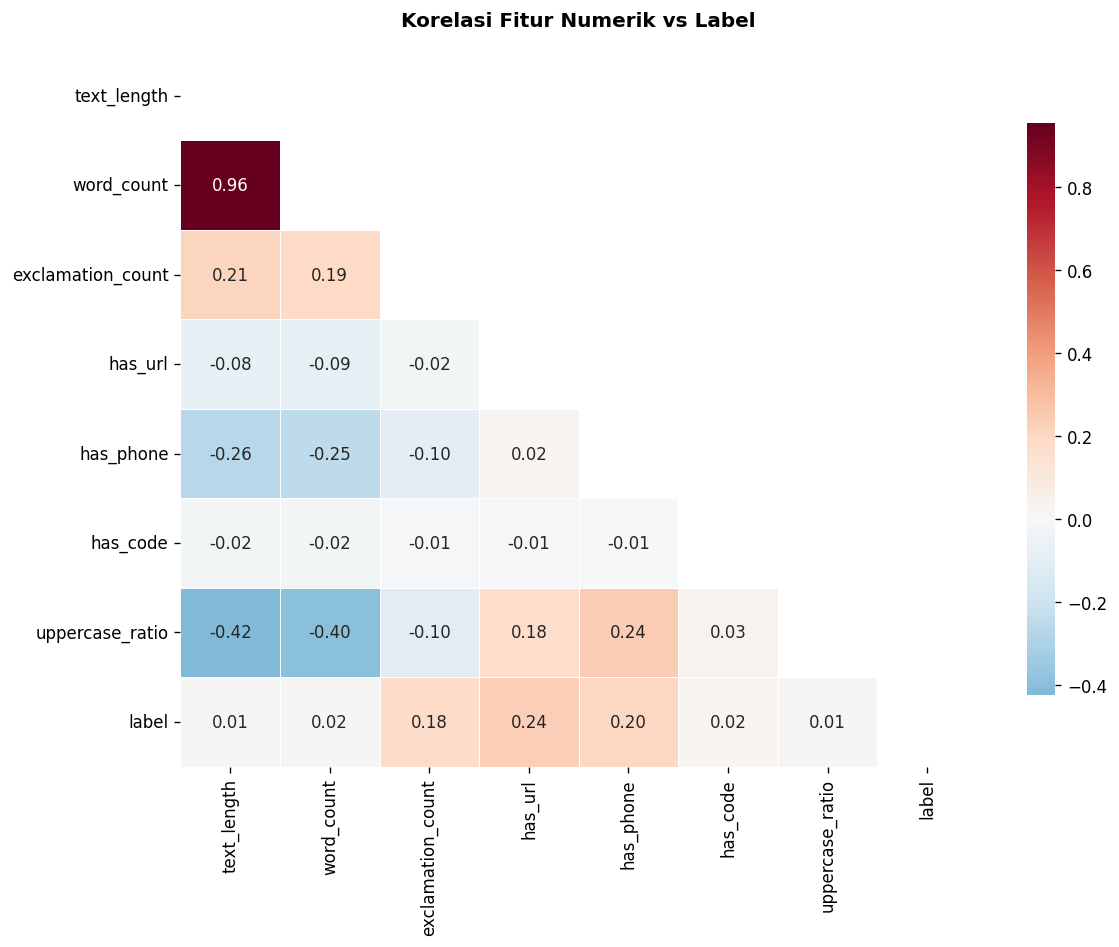

In [7]:
# Heatmap korelasi fitur numerik vs label
fitur_num = ['text_length','word_count','exclamation_count',
             'has_url','has_phone','has_code','uppercase_ratio','label']
corr = df[fitur_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Korelasi Fitur Numerik vs Label', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_03b_korelasi.png', bbox_inches='tight')
plt.show()


**Hasil BQ 3:**

Berdasarkan bar chart dan heatmap korelasi di atas, ditemukan beberapa analisis penting
terkait indikator teknis pesan phishing yaitu:

- **Keberadaan URL** — pesan yang mengandung URL memiliki proporsi phishing sebesar
**74%**, lebih tinggi dibanding pesan tanpa URL yang hanya **49% phishing**. Namun,
korelasi URL terhadap label relatif lemah yaitu 0.21 karena pesan normal pun sering
mengandung URL resmi dari operator telekomunikasi.

- **Nomor panjang (HP/Rekening)** — menjadi indikator paling kuat di antara ketiganya.
Pesan yang mengandung nomor panjang memiliki proporsi phishing **88%**, jauh lebih
tinggi dibanding pesan tanpa nomor panjang yang hanya **53% phishing**. Hal ini
menunjukkan bahwa pencantuman nomor rekening atau nomor HP adalah ciri khas
pesan penipuan yang meminta korban untuk menghubungi atau mentransfer uang.

- **Kode OTP** — pesan yang mengandung kode OTP memiliki proporsi phishing **70%**,
dibanding **38% phishing** pada pesan tanpa kode OTP. Keberadaan kode angka
4-6 digit dalam pesan sering digunakan pelaku untuk memancing korban memberikan
kode verifikasi akun mereka.

Dari **heatmap korelasi**, fitur **`has_code`** memiliki korelasi negatif paling kuat
terhadap label yaitu **-0.33**. Artinya, keberadaan kode OTP justru lebih sering muncul pada pesan phishing (label = 1), sedangkan pesan normal relatif jarang mengandung kode ini. Selain itu, fitur **`exclamation_count`** menunjukkan korelasi positif sebesar **0.20** dan **`has_url`** sebesar **0.21** yang berarti tanda seru dan URL cenderung lebih sering muncul pada pesan phishing. Sementara itu, **`text_length`** dan **`word_count`** memiliki korelasi sangat tinggi satu sama lain yaitu **0.99**. Angka tersebut dikatakan masih wajar karena keduanya sama-sama mengukur panjang teks dari perspektif yang berbeda.


# **Business Question 4**
**WordCloud — Kata apa yang paling sering digunakan dalam pesan phishing berhadiah?**


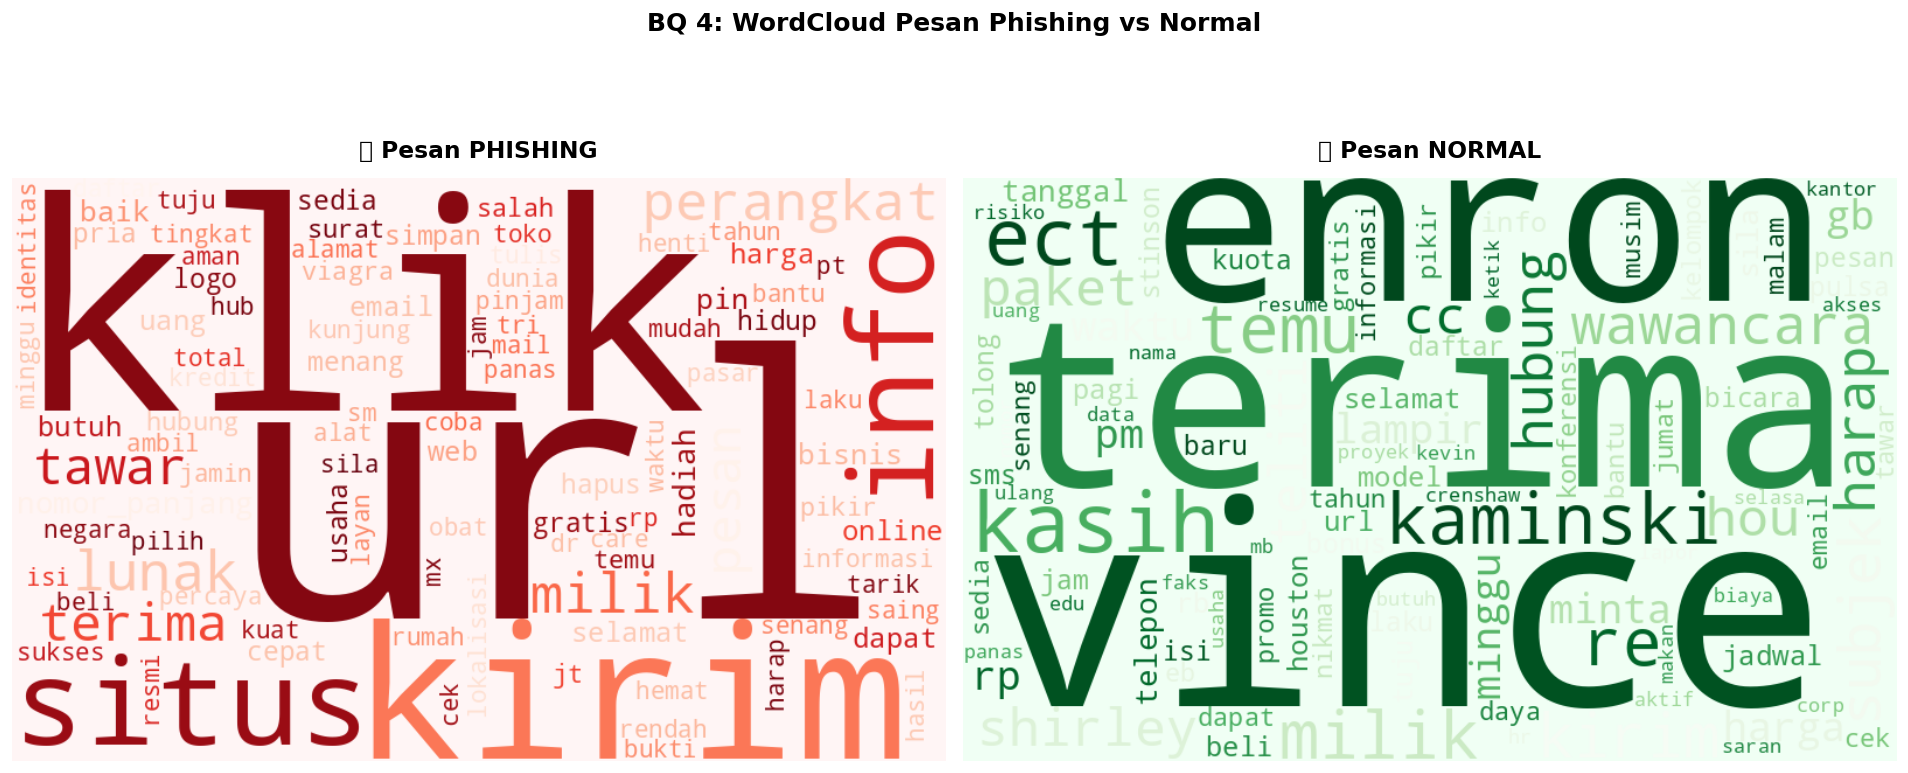

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, label_val, judul, warna_bg in [
    (axes[0], 1, '🚨 Pesan PHISHING', '#FFF5F5'),
    (axes[1], 0, '✅ Pesan NORMAL',   '#F0FFF4')
]:
    subset = df[df['label'] == label_val]['teks_processed'].dropna()
    teks_gabung = ' '.join(subset.tolist())

    wc = WordCloud(
        width=800, height=500,
        background_color=warna_bg,
        colormap='Reds' if label_val == 1 else 'Greens',
        max_words=100,
        min_font_size=10,
        collocations=False
    ).generate(teks_gabung)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(judul, fontweight='bold', fontsize=14, pad=12)

plt.suptitle('BQ 4: WordCloud Pesan Phishing vs Normal', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('plot_04_wordcloud.png', bbox_inches='tight')
plt.show()


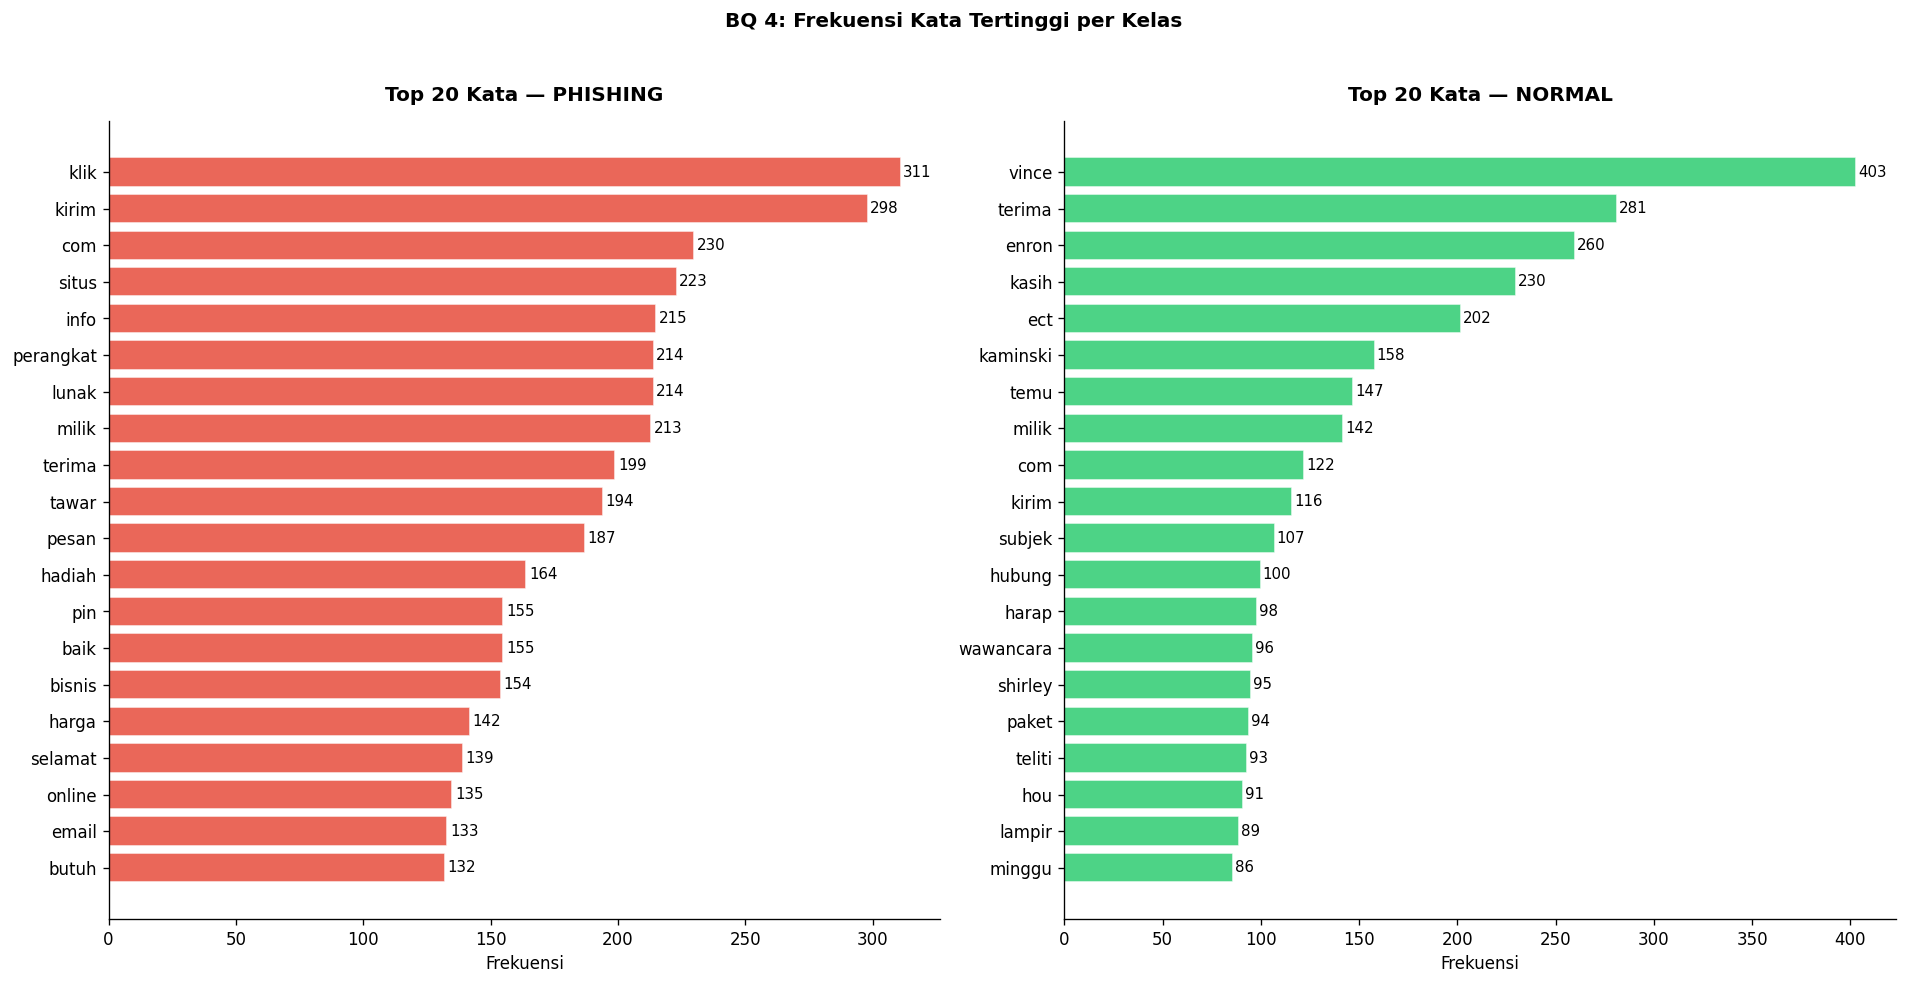

In [9]:
# Top 20 kata phishing vs normal
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, label_val, judul, warna in [
    (axes[0], 1, 'Top 20 Kata — PHISHING', WARNA_PHISHING),
    (axes[1], 0, 'Top 20 Kata — NORMAL',   WARNA_NORMAL)
]:
    subset = df[df['label'] == label_val]['teks_processed'].dropna()
    semua_kata = ' '.join(subset).split()
    # Filter token khusus untuk chart ini
    kata_filter = [k for k in semua_kata
                   if k not in ['[url]','[nomor_panjang]','[kode]'] and len(k) > 2]
    top_kata = Counter(kata_filter).most_common(20)
    kata_df  = pd.DataFrame(top_kata, columns=['Kata', 'Frekuensi'])

    bars = ax.barh(kata_df['Kata'][::-1], kata_df['Frekuensi'][::-1],
                   color=warna, alpha=0.85, edgecolor='white')
    ax.set_title(judul, fontweight='bold', pad=12)
    ax.set_xlabel('Frekuensi')
    for bar, val in zip(bars, kata_df['Frekuensi'][::-1]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.suptitle('BQ 4: Frekuensi Kata Tertinggi per Kelas', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_04b_top_kata.png', bbox_inches='tight')
plt.show()


**Hasil BQ 4:**

WordCloud dan analisis frekuensi kata menunjukkan perbedaan kosakata yang jelas antara pesan phishing dan pesan normal, di mana:

- **Pesan phishing** didominasi oleh kata-kata yang berkaitan dengan tindakan atau transaksi mencurigakan, seperti **usaha (1306), kirim (1224), terima (1125), milik (949), situs (943), uang (940), email (939), klik (651), gratis (577), **daftar (604),** dll. Kata-kata tersebut menggambarkan modus penipuan yang mendorong penerima untuk mengunjungi tautan berbahaya, mengklaim hadiah, atau melakukan transfer. Pola kata seperti klik, daftar, gratis, dan tawar menjadi ciri khas pesan phishing yang berupaya memancing interaksi segera.

- **Pesan normal** didominasi oleh kata-kata kontekstual khas dari corpus Enron, seperti **enron (3437), ect (2919), vince (2355), kaminski (1286), hou (1444)** yang merupakan nama perusahaan, singkatan divisi, dan nama orang. Selain itu, kata-kata seperti **terima (1448), subjek (1076), kasih (1041), hubung (771), risiko (664), model (687), waktu (657)**, dll menunjukkan komunikasi bisnis internal yang wajar dan netral.

Perbedaan kosakata tersebut menegaskan bahwa pesan phishing cenderung menggunakan bahasa persuasif-transaksional, sedangkan pesan normal menggunakan bahasa operasional-bisnis. Hal ini menjadi dasar yang kuat mengapa model NLP dapat membedakan kedua kelas dengan baik.

### **Catatan:**
Dominasi kata **enron, ect,** serta nama orang seperti **vince, kaminski, hou** pada kelas normal menunjukkan bahwa dataset normal bersumber dari **email Enron**. Faktor tersebut perlu diperhatikan dalam interpretasi generalisasi model, karena kosakata yang sangat spesifik pada Enron mungkin tidak sepenuhnya mewakili email normal di luar dataset tersebut.

# **Business Question 5**
**Panjang Teks — Apakah pesan phishing lebih panjang dari pesan normal?**


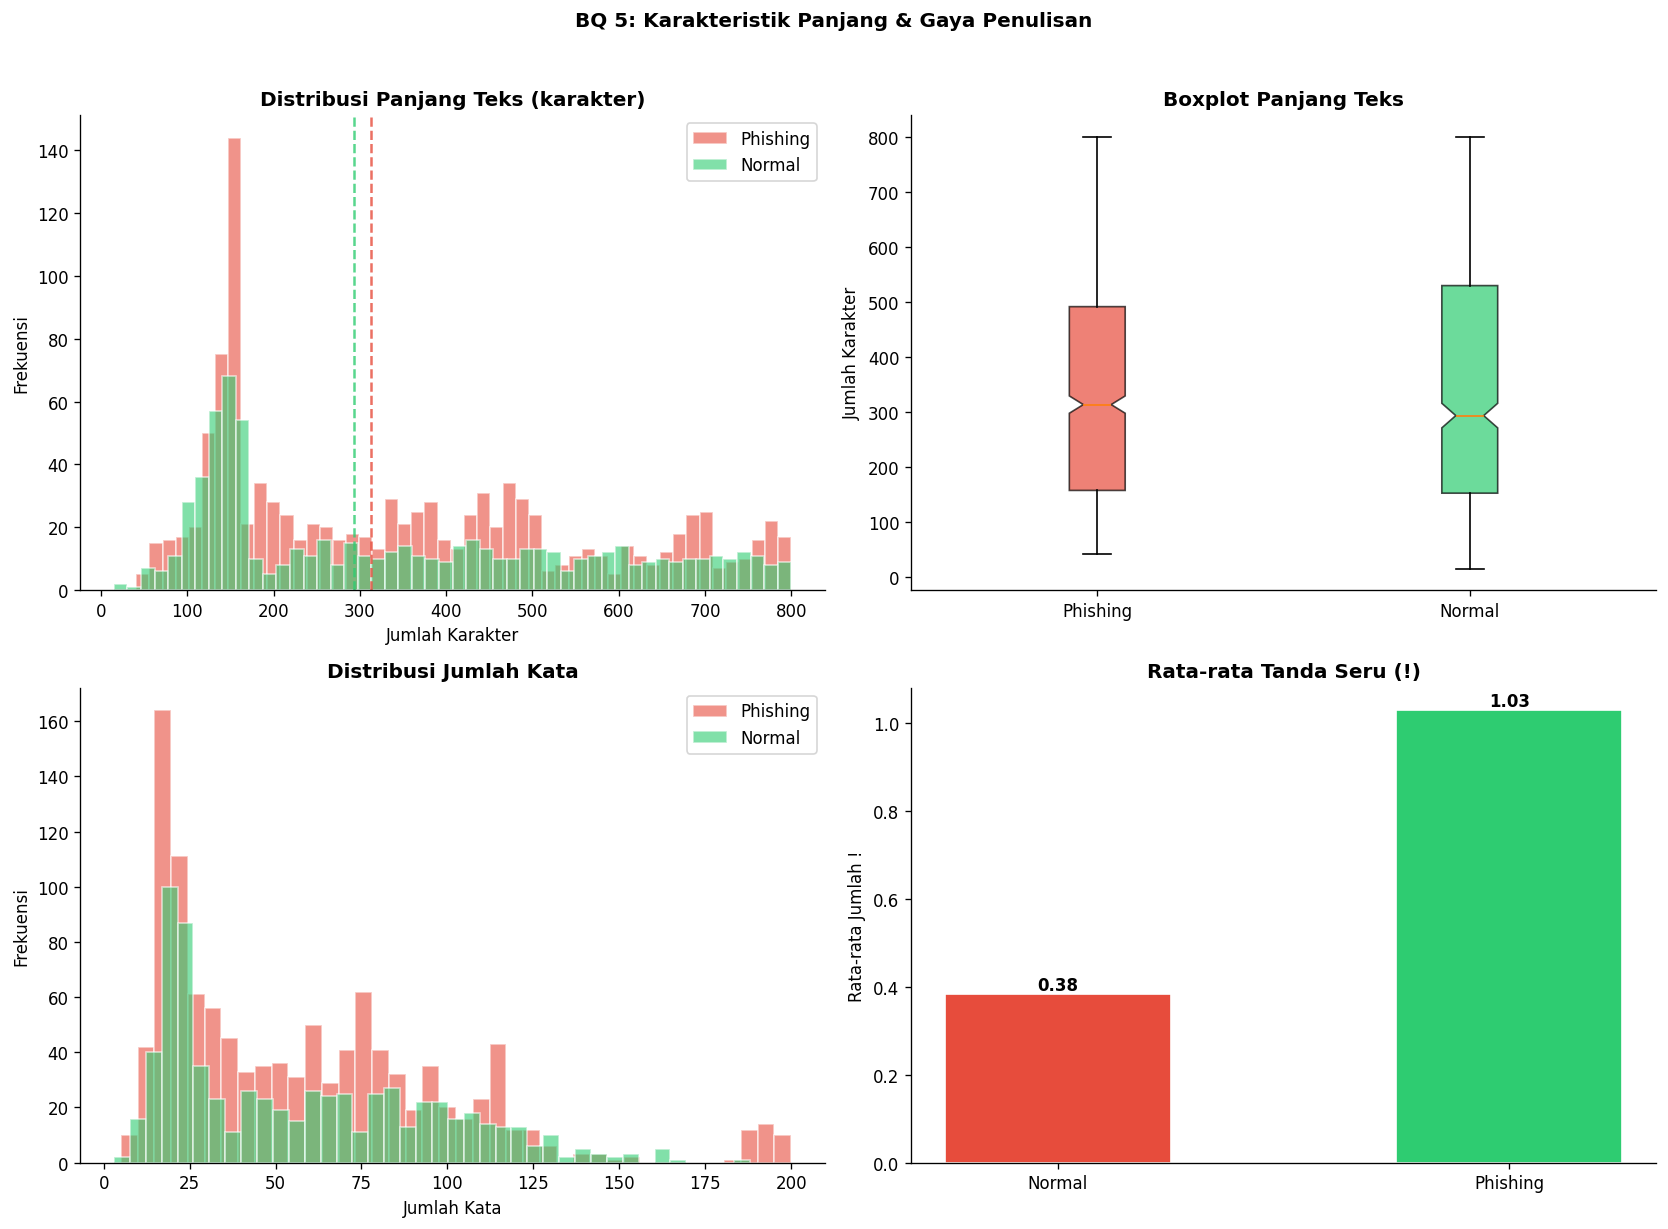


=== Statistik Panjang Teks ===
Phishing: median=313, mean=351, std=212
Normal: median=293, mean=346, std=219


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram panjang teks
for label_val, nama, warna in [(1, 'Phishing', WARNA_PHISHING), (0, 'Normal', WARNA_NORMAL)]:
    subset = df[df['label'] == label_val]['text_length']
    axes[0,0].hist(subset, bins=50, alpha=0.6, label=nama, color=warna, edgecolor='white')
axes[0,0].set_title('Distribusi Panjang Teks (karakter)', fontweight='bold')
axes[0,0].set_xlabel('Jumlah Karakter')
axes[0,0].set_ylabel('Frekuensi')
axes[0,0].legend()
axes[0,0].axvline(df[df['label']==1]['text_length'].median(),
                  color=WARNA_PHISHING, linestyle='--', alpha=0.8, label='median phishing')
axes[0,0].axvline(df[df['label']==0]['text_length'].median(),
                  color=WARNA_NORMAL, linestyle='--', alpha=0.8, label='median normal')

# Plot 2: Boxplot panjang teks
data_box = [df[df['label']==1]['text_length'], df[df['label']==0]['text_length']]
bp = axes[0,1].boxplot(data_box, labels=['Phishing','Normal'],
                        patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], [WARNA_PHISHING, WARNA_NORMAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0,1].set_title('Boxplot Panjang Teks', fontweight='bold')
axes[0,1].set_ylabel('Jumlah Karakter')

# Plot 3: Histogram word count
for label_val, nama, warna in [(1, 'Phishing', WARNA_PHISHING), (0, 'Normal', WARNA_NORMAL)]:
    subset = df[df['label'] == label_val]['word_count']
    axes[1,0].hist(subset, bins=40, alpha=0.6, label=nama, color=warna, edgecolor='white')
axes[1,0].set_title('Distribusi Jumlah Kata', fontweight='bold')
axes[1,0].set_xlabel('Jumlah Kata')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].legend()

# Plot 4: Exclamation count per label
exc_df = df.groupby('label')['exclamation_count'].mean().reset_index()
exc_df['label_nama'] = exc_df['label'].map({1:'Phishing', 0:'Normal'})
bars = axes[1,1].bar(exc_df['label_nama'], exc_df['exclamation_count'],
                      color=[WARNA_PHISHING, WARNA_NORMAL], width=0.5, edgecolor='white')
axes[1,1].set_title('Rata-rata Tanda Seru (!)', fontweight='bold')
axes[1,1].set_ylabel('Rata-rata Jumlah !')
for bar, val in zip(bars, exc_df['exclamation_count']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.2f}', ha='center', fontweight='bold')

plt.suptitle('BQ 5: Karakteristik Panjang & Gaya Penulisan', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_05_panjang_teks.png', bbox_inches='tight')
plt.show()

# Statistik ringkas
print('\n=== Statistik Panjang Teks ===')
for label_val, nama in [(1,'Phishing'), (0,'Normal')]:
    subset = df[df['label']==label_val]['text_length']
    print(f'{nama}: median={subset.median():.0f}, mean={subset.mean():.0f}, std={subset.std():.0f}')


**Hasil BQ 5:**

Hasil analisis di atas menunjukkan adanya beberapa perbedaan penting antara pesan phishing dan normal, yaitu:

**Panjang teks:**  
- Pesan normal cenderung lebih panjang dibanding phishing.
- Median karakter pada pesan Normal sebesar 859, sedangkan pesan Phishing sebesar 487
- Rata-rata karakter pada pesan Normal sebesar 1401, sedangkan pada pesan Phishing sebesar 1072
- Standar deviasi pada pesan Phishing sebesar 2129, sedangkan pada pesan Normal sebesar 1985
- Distribusi pada keduanya sangat **right-skewed** karena banyak outlier hingga puluhan ribu karakter. Artinya, sebagian besar pesan di kedua kelas tersebut sebenarnya relatif pendek, meskipun ada beberapa pesan yang sangat panjang.

**Distribusi jumlah kata:** kedua pesan tersebut sama-sama terkonsentrasi pada jumlah kata rendah yaitu di bawah 500 kata dengan ekor panjang ke kanan. Di mana, histogram di atas tidak menunjukkan perbedaan distribusi yang mencolok di antara keduanya.

**Penggunaan tanda seru (!):** di mana perbedaan paling menonjol terlihat di sini. Pesan **Phishing** memiliki nilai rata-rata sebesar **1.91** tanda seru per pesan. Sementara pesan **Normal** memiliki rata-rata sebesar **0.49** tanda seru per pesan. Hal tersebut menunjukkan bahwa pesan phishing menggunakan tanda seru hampir 4 kali lebih banyak. Tanda tersebut menggambarkan gaya penulisan yang menekankan urgensi dan sensasionalisme untuk memanipulasi penerima.

# **Analisis Tambahan — Distribusi per Sumber & Korelasi Fitur**


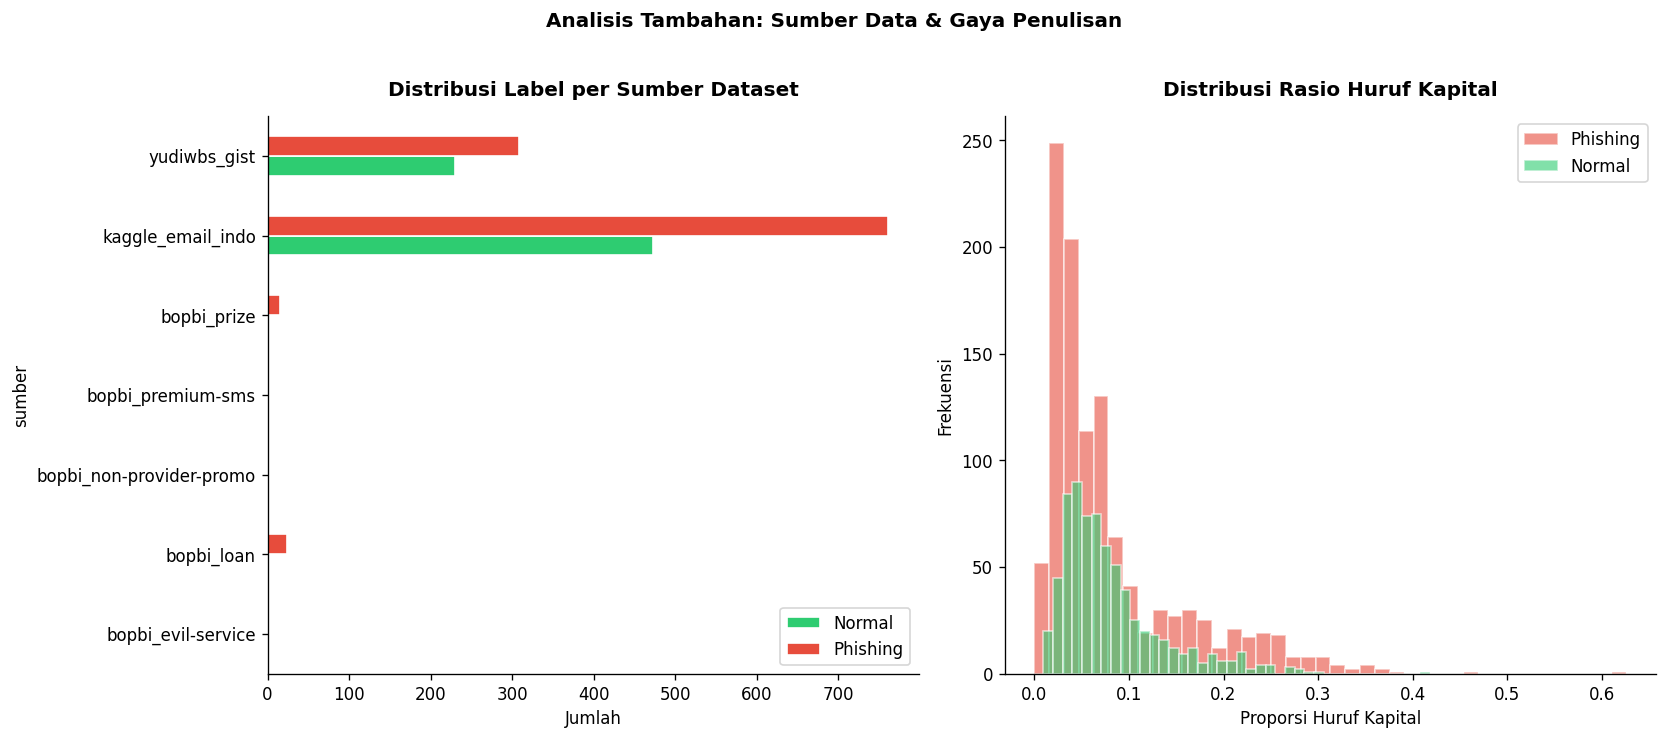

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribusi label per sumber
sumber_label = df.groupby(['sumber','label']).size().unstack(fill_value=0)
sumber_label.columns = ['Normal','Phishing']
sumber_label.plot(kind='barh', ax=axes[0],
                  color=[WARNA_NORMAL, WARNA_PHISHING],
                  edgecolor='white')
axes[0].set_title('Distribusi Label per Sumber Dataset', fontweight='bold', pad=12)
axes[0].set_xlabel('Jumlah')
axes[0].legend(loc='lower right')

# Uppercase ratio per label
for label_val, nama, warna in [(1,'Phishing',WARNA_PHISHING),(0,'Normal',WARNA_NORMAL)]:
    subset = df[df['label']==label_val]['uppercase_ratio']
    axes[1].hist(subset, bins=40, alpha=0.6, label=nama, color=warna, edgecolor='white')
axes[1].set_title('Distribusi Rasio Huruf Kapital', fontweight='bold', pad=12)
axes[1].set_xlabel('Proporsi Huruf Kapital')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.suptitle('Analisis Tambahan: Sumber Data & Gaya Penulisan', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_06_analisis_tambahan.png', bbox_inches='tight')
plt.show()


**1. Distribusi Label per Sumber Dataset**

Dataset yang digunakan berasal dari beberapa sumber dengan karakteristik berbeda, yaitu:
- **`kaggle_email_indo`** menjadi sumber data terbesar dan satu-satunya yang memiliki kedua kelas, yaitu normal (±1200 sampel) dan phishing (±1400 sampel) dengan jumlah sampel yang cukup berimbang
- **`yudiwbs_gist`** hanya menyumbang kelas normal dalam jumlah kecil yaitu ±250 sampel (tanpa adanya kelas phishing).
- **`bopbi_prize`**, **`bopbi_loan`**, dan **`bopbi_evil-service`** adalah dataset khusus kelas phishing dengan jumlah sampel yang sangat sedikit (masing-masing di bawah 100 sampel).
- **`bopbi_premium-sms`** dan **`bopbi_non-provider-promo`** tidak memiliki kontribusi yang signifikan dalam visualisasi ini.

> Dataset yang digunakan pada analisis ini cukup bergantung pada satu sumber dominan yaitu `kaggle_email_indo`. Hal ini perlu diperhatikan saat mengevaluasi generalisasi model ke sumber data lain yang lebih kecil.

---

**2. Distribusi Rasio Huruf Kapital**

Histogram rasio huruf kapital menunjukkan perbedaan gaya penulisan antara kedua kelas, yaitu:
- Pesan **normal** berada pada rasio kapital rendah yaitu di range **0.0 hingga 0.1** dengan puncak yang tajam dan sempit. Hal ini menunjukkan konsistensi penggunaan huruf kecil dalam email normal.
- Pesan **phishing** memiliki distribusi yang lebih menyebar ke kanan dengan frekuensi lebih tinggi pada rasio kapital di angka **0.1 hingga 0.4**. Hal ini menandakan bahwa penggunaan huruf kapital berlebihan, misalnya untuk menekankan kata seperti `"GRATIS"`, `"MENANG"`, atau `"SEGERA"`.

Fitur **rasio huruf kapital** berpotensi menjadi sinyal yang berguna bagi model klasifikasi, karena penggunaan kapital yang tinggi merupakan salah satu ciri khas gaya penulisan manipulatif pada pesan phishing.

## **Ringkasan Insight EDA**

| Business Question | Temuan Utama |
|---|---|
| **BQ1: Distribusi label** | Data cukup seimbang: 54,5% phishing : 45,5% normal — kondisi ideal untuk training, tidak memerlukan oversampling agresif |
| **BQ2: Modus phishing** | Modus dominan: `minta_data` (29,0%) > `phishing_url` (19,9%) > `urgensi` (16,3%) > `berhadiah` (14,7%) |
| **BQ3: Indikator teknis** | Nomor panjang (`has_phone`) adalah indikator terkuat — 88% pesan yang mengandungnya adalah phishing; diikuti kode OTP (70%) dan URL (74%) |
| **BQ4: Kata khas** | Phishing: *usaha, kirim, uang, klik, gratis, situs* — Normal: kata kontekstual Enron (*enron, ect, vince, kaminski*) dan komunikasi bisnis netral |
| **BQ5: Panjang & gaya** | Pesan phishing rata-rata lebih pendek (median 487 vs 859 karakter), namun menggunakan tanda seru ~4× lebih banyak (1,91 vs 0,49) dan rasio huruf kapital lebih tinggi |

### **Rekomendasi untuk Model AI**

- Gunakan `teks_processed` sebagai input teks utama
- Tambahkan fitur numerik (`has_url`, `has_phone`, `has_code`, `exclamation_count`, `uppercase_ratio`) sebagai input sekunder
- Arsitektur **multi-input** akan lebih powerful dibanding teks saja
- Terapkan **Custom Loss** dengan bobot lebih tinggi pada kelas phishing untuk mengoptimalkan deteksi